# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## 🕸️ Phase 3 — Construction et Analyse du Graphe Biparti

---

### 🎯 Objectif de cette phase
- Construire le **graphe biparti Gène ↔ Maladie** avec NetworkX
- Analyser la **structure** du graphe (degrés, composantes, hubs)
- **Visualiser** le graphe et ses propriétés
- Sauvegarder le graphe pour les phases suivantes

---

### 📖 Rappel théorique : Graphe Biparti

Un graphe biparti G = (U ∪ V, E) possède deux ensembles de nœuds :
- **U** = ensemble des Gènes 🧬
- **V** = ensemble des Maladies 🦠
- **E** = ensemble des arêtes (associations validées)

**Règle fondamentale :** les arêtes relient UNIQUEMENT un gène à une maladie.
Jamais gène↔gène, jamais maladie↔maladie.

```
  GÈNES          MALADIES
  ──────         ────────
  TP53   ───────► Cancer du sein
  TP53   ───────► Leucémie
  BRCA1  ───────► Cancer du sein
  TTN    ───────► Cardiomyopathie
```

## ⚙️ Cellule 1 — Installation et importation des bibliothèques

In [1]:
# Décommente si nécessaire :
# !pip install networkx matplotlib seaborn pandas numpy

import os
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 7)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('✅ Toutes les bibliothèques sont importées !')
print(f'   NetworkX version : {nx.__version__}')

✅ Toutes les bibliothèques sont importées !
   NetworkX version : 3.4.2


## 📁 Cellule 2 — Chargement des données (Phase 2)

In [2]:
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROC_DIR   = os.path.join(BASE_DIR, 'data', 'processed')
GRAPH_DIR  = os.path.join(BASE_DIR, 'data', 'graph')
FIG_DIR    = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

EDGES_FILE = os.path.join(PROC_DIR, 'gene_disease_edges.csv')
FULL_FILE  = os.path.join(PROC_DIR, 'gene_disease_full.csv')

# Chargement
df_edges = pd.read_csv(EDGES_FILE, dtype=str)
df_full  = pd.read_csv(FULL_FILE,  dtype=str)

print(f'✅ Données chargées !')
print(f'   Arêtes      : {len(df_edges):,}')
print(f'   Colonnes    : {df_edges.columns.tolist()}')
print()
df_edges.head(8)

✅ Données chargées !
   Arêtes      : 15,940
   Colonnes    : ['gene_id', 'disease_id']



,gene_id,disease_id
0,64170,OMIM:212050
1,51256,OMIM:248000
2,28981,OMIM:617895
3,8216,OMIM:616564
4,6505,OMIM:615232
5,5949,OMIM:615233
6,583,OMIM:616562
7,4750,OMIM:617892


## 🕸️ Cellule 3 — Construction du Graphe Biparti

> On ajoute un préfixe à chaque nœud pour distinguer les gènes des maladies :
> - Gène `64170` devient `G_64170`
> - Maladie `OMIM:212050` devient `D_OMIM:212050`

In [12]:
# ── Création du graphe vide
G = nx.Graph()

# ── Ajout des nœuds GÈNES (avec attribut bipartite=0)
gene_nodes = [f"G_{gid}" for gid in df_edges['gene_id'].unique()]
G.add_nodes_from(gene_nodes, bipartite=0, node_type='gene')

# ── Ajout des nœuds MALADIES (avec attribut bipartite=1)
disease_nodes = [f"D_{did}" for did in df_edges['disease_id'].unique()]
G.add_nodes_from(disease_nodes, bipartite=1, node_type='disease')

# ── Ajout des ARÊTES (associations gène-maladie)
edges = [
    (f"G_{row['gene_id']}", f"D_{row['disease_id']}")
    for _, row in df_edges.iterrows()
]
G.add_edges_from(edges)

print('╔══════════════════════════════════════════════╗')
print('║       🕸️ GRAPHE BIPARTI CONSTRUIT !          ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Nœuds GÈNES     : {len(gene_nodes):>6,}                    ║')
print(f'║  Nœuds MALADIES  : {len(disease_nodes):>6,}                    ║')
print(f'║  Total nœuds     : {G.number_of_nodes():>6,}                    ║')
print(f'║  Total arêtes    : {G.number_of_edges():>6,}                    ║')
print('╚══════════════════════════════════════════════╝')

# ── Vérification que c'est bien un graphe biparti
is_bip = bipartite.is_bipartite(G)
print(f'\n✅ Vérification biparti : {is_bip}')

╔══════════════════════════════════════════════╗
║       🕸️ GRAPHE BIPARTI CONSTRUIT !          ║
╠══════════════════════════════════════════════╣
║  Nœuds GÈNES     :  5,529                    ║
║  Nœuds MALADIES  : 11,026                    ║
║  Total nœuds     : 16,555                    ║
║  Total arêtes    : 15,940                    ║
╚══════════════════════════════════════════════╝

✅ Vérification biparti : True


## 📊 Cellule 4 — Propriétés globales du Graphe

In [13]:
# ── Densité
n_genes    = len(gene_nodes)
n_diseases = len(disease_nodes)
n_edges    = G.number_of_edges()
density    = n_edges / (n_genes * n_diseases)

# ── Composantes connexes
components       = list(nx.connected_components(G))
n_components     = len(components)
largest_comp     = max(components, key=len)
largest_comp_pct = len(largest_comp) / G.number_of_nodes() * 100

# ── Degré moyen
avg_degree_genes    = np.mean([G.degree(n) for n in gene_nodes])
avg_degree_diseases = np.mean([G.degree(n) for n in disease_nodes])

print('═' * 55)
print('   📐 PROPRIÉTÉS GLOBALES DU GRAPHE BIPARTI')
print('═' * 55)
print(f'  Nœuds gènes              : {n_genes:>7,}')
print(f'  Nœuds maladies           : {n_diseases:>7,}')
print(f'  Arêtes (associations)    : {n_edges:>7,}')
print(f'  Densité                  : {density:>7.6f}')
print(f'  Degré moyen (gènes)      : {avg_degree_genes:>7.2f} maladies/gène')
print(f'  Degré moyen (maladies)   : {avg_degree_diseases:>7.2f} gènes/maladie')
print()
print(f'  Composantes connexes     : {n_components:>7,}')
print(f'  Taille grande composante : {len(largest_comp):>7,} nœuds ({largest_comp_pct:.1f}%)')
print('═' * 55)
print()
print('💡 Interprétation :')
print(f'   → Un gène est associé EN MOYENNE à {avg_degree_genes:.1f} maladies')
print(f'   → Une maladie implique EN MOYENNE {avg_degree_diseases:.1f} gènes')
if n_components == 1:
    print('   → Le graphe est CONNEXE : tous les nœuds sont reliés')
else:
    print(f'   → Le graphe a {n_components} composantes : certains nœuds sont isolés')

═══════════════════════════════════════════════════════
   📐 PROPRIÉTÉS GLOBALES DU GRAPHE BIPARTI
═══════════════════════════════════════════════════════
  Nœuds gènes              :   5,529
  Nœuds maladies           :  11,026
  Arêtes (associations)    :  15,940
  Densité                  : 0.000261
  Degré moyen (gènes)      :    2.88 maladies/gène
  Degré moyen (maladies)   :    1.45 gènes/maladie

  Composantes connexes     :   2,381
  Taille grande composante :   8,396 nœuds (50.7%)
═══════════════════════════════════════════════════════

💡 Interprétation :
   → Un gène est associé EN MOYENNE à 2.9 maladies
   → Une maladie implique EN MOYENNE 1.4 gènes
   → Le graphe a 2381 composantes : certains nœuds sont isolés


## 🔬 Cellule 5 — Analyse des composantes connexes

📊 Répartition des 2381 composantes connexes :

  Grande composante : 8,396 nœuds (50.7%)
  2ème composante   : 48 nœuds
  3ème composante   : 32 nœuds

  Nœuds isolés (taille=1)   : 0
  Petites composantes (2-5)  : 2171
  Moyennes composantes (6-50): 209
  Grandes composantes (>50)  : 1


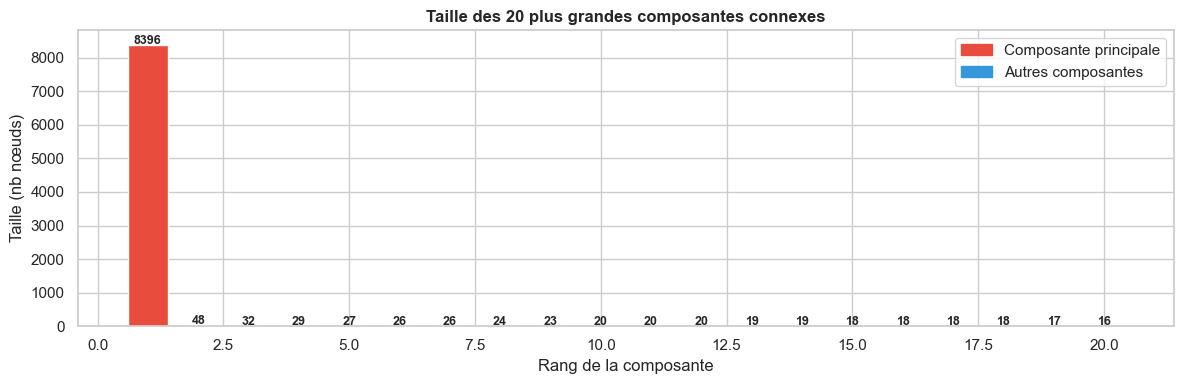

In [15]:
comp_sizes = sorted([len(c) for c in components], reverse=True)

print(f'📊 Répartition des {n_components} composantes connexes :\n')
print(f'  Grande composante : {comp_sizes[0]:,} nœuds ({comp_sizes[0]/G.number_of_nodes()*100:.1f}%)')

if len(comp_sizes) > 1:
    print(f'  2ème composante   : {comp_sizes[1]:,} nœuds')
if len(comp_sizes) > 2:
    print(f'  3ème composante   : {comp_sizes[2]:,} nœuds')

isolees = sum(1 for s in comp_sizes if s == 1)
petites = sum(1 for s in comp_sizes if 1 < s <= 5)
moyennes= sum(1 for s in comp_sizes if 5 < s <= 50)
grandes = sum(1 for s in comp_sizes if s > 50)

print(f'\n  Nœuds isolés (taille=1)   : {isolees}')
print(f'  Petites composantes (2-5)  : {petites}')
print(f'  Moyennes composantes (6-50): {moyennes}')
print(f'  Grandes composantes (>50)  : {grandes}')

# Visualisation
fig, ax = plt.subplots(figsize=(12, 4))
top_sizes = comp_sizes[:20]
colors = ['#E74C3C' if i == 0 else '#3498DB' for i in range(len(top_sizes))]
bars = ax.bar(range(1, len(top_sizes)+1), top_sizes, color=colors, edgecolor='white')

for i, (bar, val) in enumerate(zip(bars, top_sizes)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            str(val), ha='center', fontsize=9, fontweight='bold')

patch1 = mpatches.Patch(color='#E74C3C', label='Composante principale')
patch2 = mpatches.Patch(color='#3498DB', label='Autres composantes')
ax.legend(handles=[patch1, patch2])
ax.set_xlabel('Rang de la composante')
ax.set_ylabel('Taille (nb nœuds)')
ax.set_title('Taille des 20 plus grandes composantes connexes', fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Cellule 6 — Analyse des HUBS (nœuds très connectés)

In [16]:
# ── Calcul des degrés séparément pour gènes et maladies
gene_deg    = {n: G.degree(n) for n in gene_nodes}
disease_deg = {n: G.degree(n) for n in disease_nodes}

# ── Créer des DataFrames pour mieux afficher
df_gene_deg = pd.DataFrame(
    [(n.replace('G_',''), deg) for n, deg in gene_deg.items()],
    columns=['gene_id', 'degree']
).sort_values('degree', ascending=False)

df_disease_deg = pd.DataFrame(
    [(n.replace('D_',''), deg) for n, deg in disease_deg.items()],
    columns=['disease_id', 'degree']
).sort_values('degree', ascending=False)

# ── Ajouter les symboles des gènes
gene_symbol_map = df_full[['gene_id','gene_symbol']].drop_duplicates().set_index('gene_id')['gene_symbol']
df_gene_deg['gene_symbol'] = df_gene_deg['gene_id'].map(gene_symbol_map)

print('═' * 45)
print('   🏆 TOP 10 GÈNES HUBS (plus connectés)')
print('═' * 45)
top10_genes = df_gene_deg.head(10)[['gene_symbol','gene_id','degree']]
top10_genes.index = range(1, 11)
print(top10_genes.to_string())

print()
print('═' * 45)
print('   🏆 TOP 10 MALADIES HUBS (plus connectées)')
print('═' * 45)
top10_diseases = df_disease_deg.head(10)
top10_diseases.index = range(1, 11)
print(top10_diseases.to_string())

═════════════════════════════════════════════
   🏆 TOP 10 GÈNES HUBS (plus connectés)
═════════════════════════════════════════════
   gene_symbol gene_id  degree
1          HBB    3043      37
2       COL2A1    1280      35
3         TP53    7157      32
4         LMNA    4000      32
5       PIK3CA    5290      30
6        FGFR3    2261      27
7        FGFR1    2260      25
8         KRAS    3845      24
9        FGFR2    2263      23
10         KIT    3815      23

═════════════════════════════════════════════
   🏆 TOP 10 MALADIES HUBS (plus connectées)
═════════════════════════════════════════════
      disease_id  degree
1   ORPHA:528084     114
2      ORPHA:791      88
3    ORPHA:90636      74
4    ORPHA:88616      54
5   ORPHA:442835      53
6      ORPHA:244      53
7      ORPHA:154      52
8    ORPHA:90635      50
9   ORPHA:178469      43
10  ORPHA:399805      36


## 📉 Cellule 7 — Distribution des degrés (loi de puissance ?)

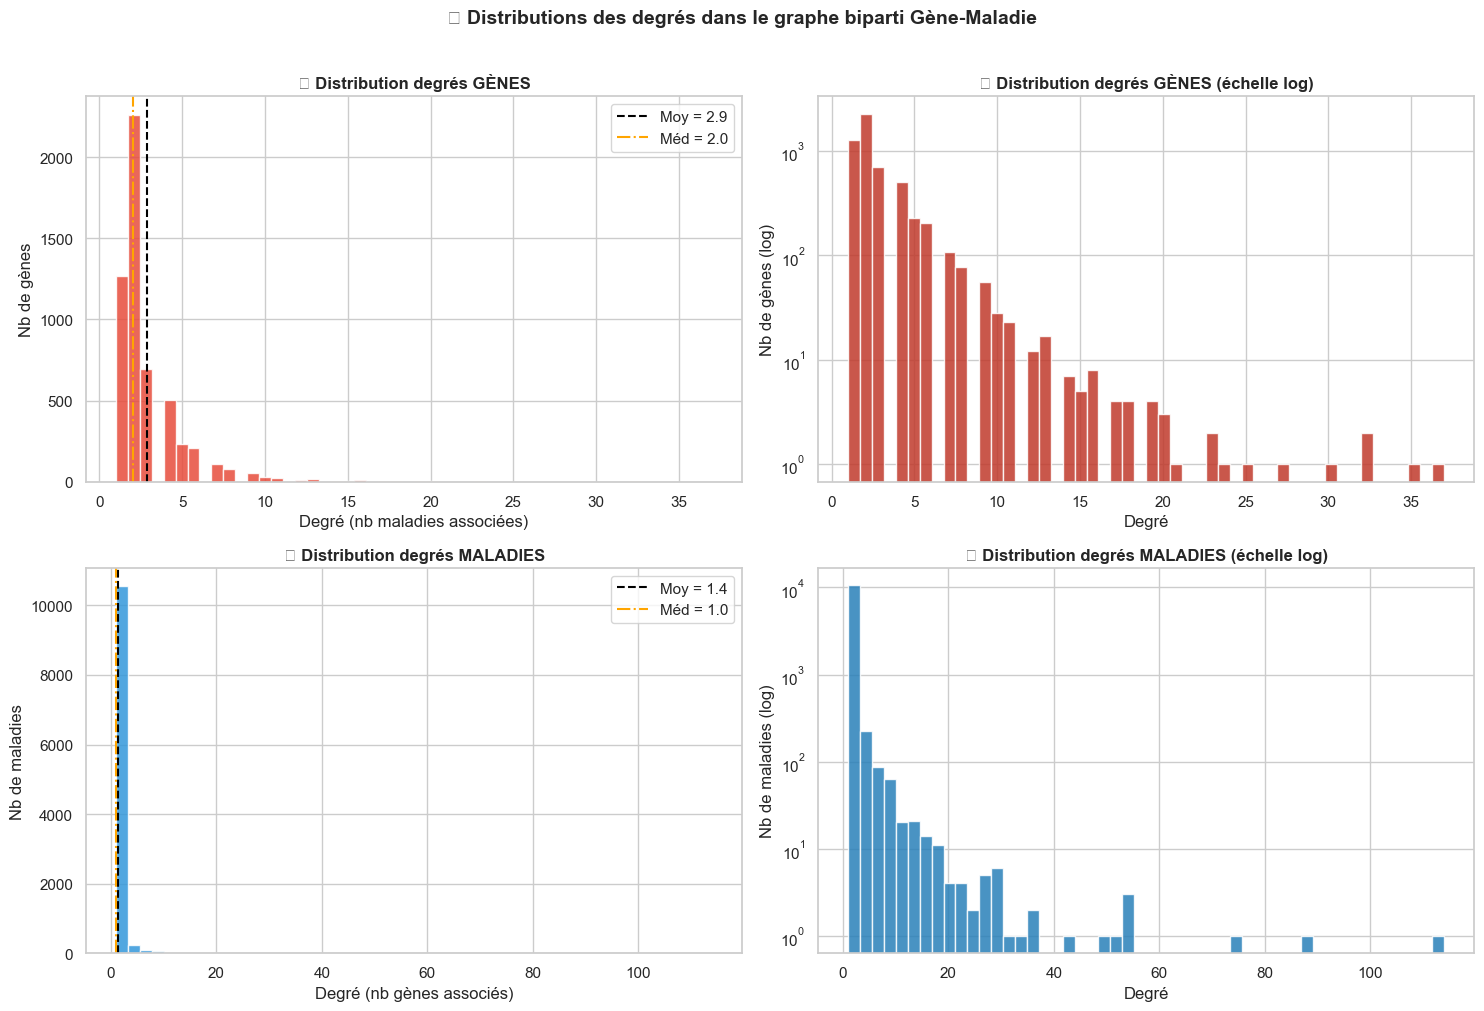

💡 Interprétation :
   → La distribution suit une LOI DE PUISSANCE (queue longue à droite)
   → Quelques hubs très connectés, beaucoup de nœuds peu connectés
   → Typique des réseaux biologiques réels (scale-free network)


In [17]:
gene_degrees_vals    = list(gene_deg.values())
disease_degrees_vals = list(disease_deg.values())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── 1. Histogramme degrés gènes (échelle normale)
axes[0,0].hist(gene_degrees_vals, bins=50, color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0,0].axvline(np.mean(gene_degrees_vals), color='black', linestyle='--',
                  label=f'Moy = {np.mean(gene_degrees_vals):.1f}')
axes[0,0].axvline(np.median(gene_degrees_vals), color='orange', linestyle='-.',
                  label=f'Méd = {np.median(gene_degrees_vals):.1f}')
axes[0,0].set_title('🧬 Distribution degrés GÈNES', fontweight='bold')
axes[0,0].set_xlabel('Degré (nb maladies associées)')
axes[0,0].set_ylabel('Nb de gènes')
axes[0,0].legend()

# ── 2. Histogramme degrés gènes (échelle log)
axes[0,1].hist(gene_degrees_vals, bins=50, color='#C0392B', alpha=0.85, edgecolor='white')
axes[0,1].set_yscale('log')
axes[0,1].set_title('🧬 Distribution degrés GÈNES (échelle log)', fontweight='bold')
axes[0,1].set_xlabel('Degré')
axes[0,1].set_ylabel('Nb de gènes (log)')

# ── 3. Histogramme degrés maladies (échelle normale)
axes[1,0].hist(disease_degrees_vals, bins=50, color='#3498DB', alpha=0.85, edgecolor='white')
axes[1,0].axvline(np.mean(disease_degrees_vals), color='black', linestyle='--',
                  label=f'Moy = {np.mean(disease_degrees_vals):.1f}')
axes[1,0].axvline(np.median(disease_degrees_vals), color='orange', linestyle='-.',
                  label=f'Méd = {np.median(disease_degrees_vals):.1f}')
axes[1,0].set_title('🦠 Distribution degrés MALADIES', fontweight='bold')
axes[1,0].set_xlabel('Degré (nb gènes associés)')
axes[1,0].set_ylabel('Nb de maladies')
axes[1,0].legend()

# ── 4. Histogramme degrés maladies (échelle log)
axes[1,1].hist(disease_degrees_vals, bins=50, color='#2980B9', alpha=0.85, edgecolor='white')
axes[1,1].set_yscale('log')
axes[1,1].set_title('🦠 Distribution degrés MALADIES (échelle log)', fontweight='bold')
axes[1,1].set_xlabel('Degré')
axes[1,1].set_ylabel('Nb de maladies (log)')

plt.suptitle('📉 Distributions des degrés dans le graphe biparti Gène-Maladie',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'degree_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interprétation :')
print('   → La distribution suit une LOI DE PUISSANCE (queue longue à droite)')
print('   → Quelques hubs très connectés, beaucoup de nœuds peu connectés')
print('   → Typique des réseaux biologiques réels (scale-free network)')

## 🎨 Cellule 8 — Visualisation du graphe complet (sous-ensemble)

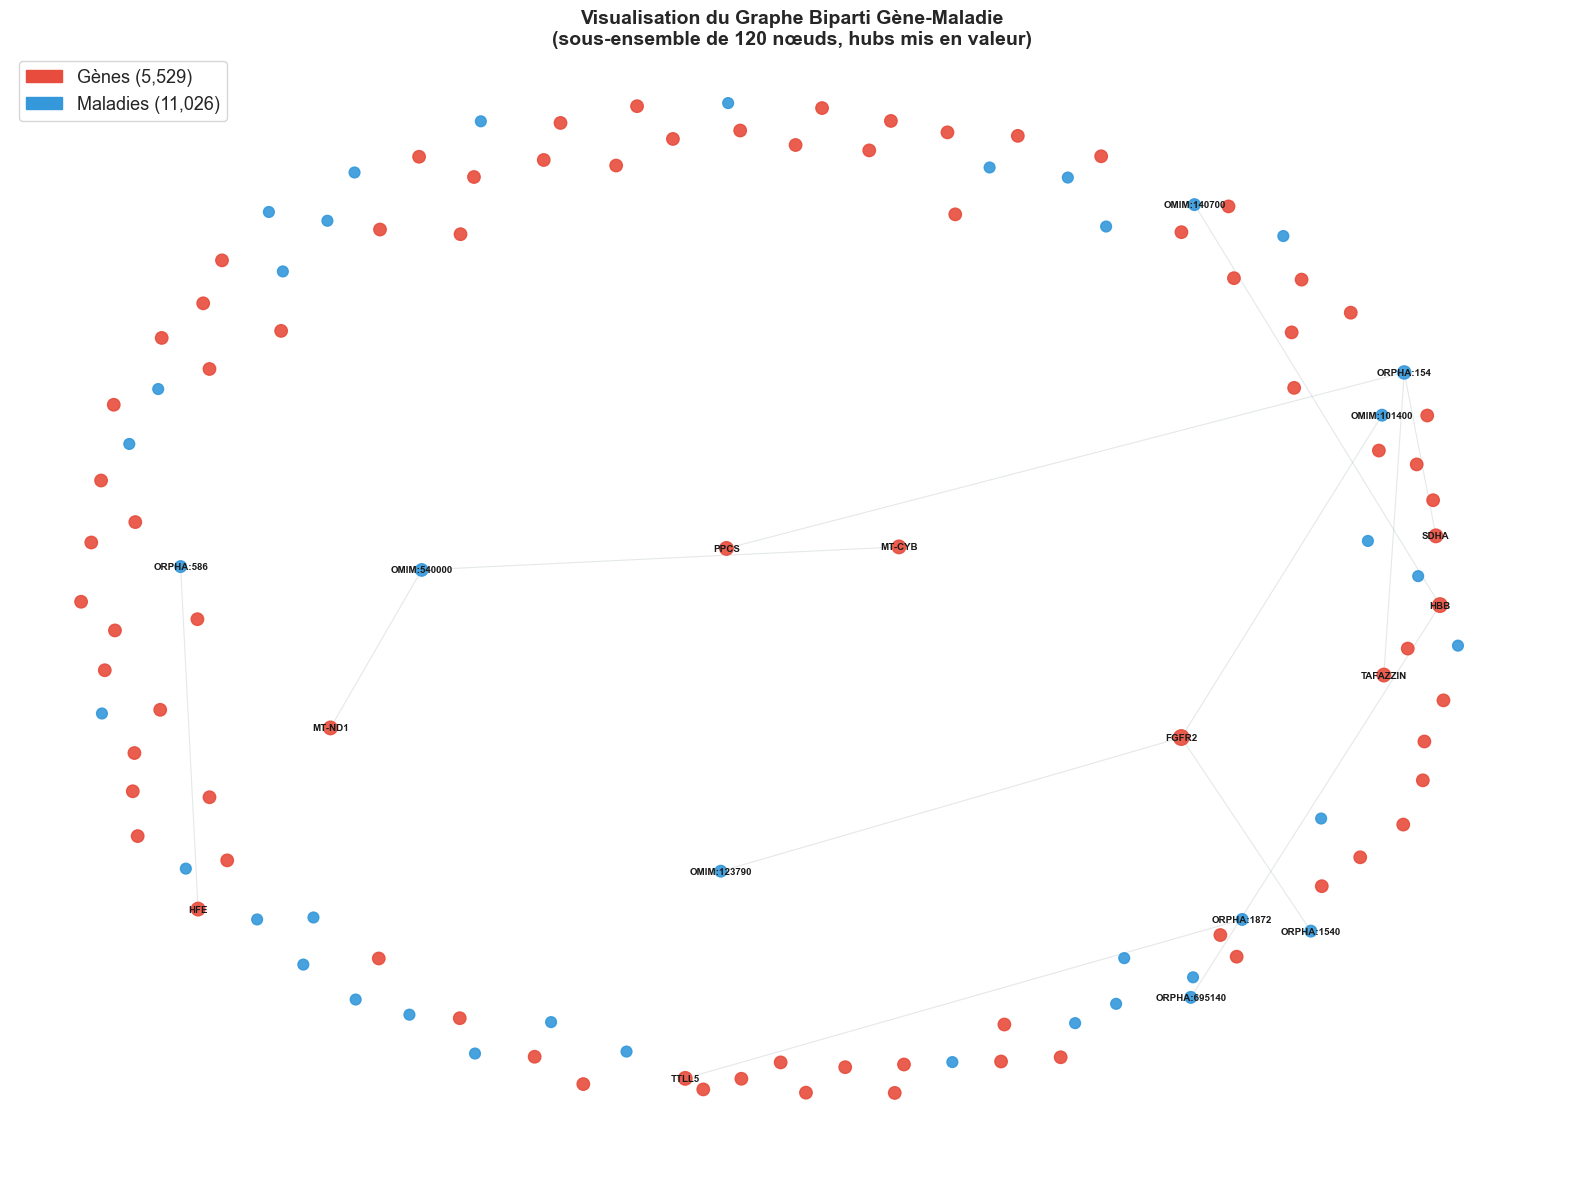

💾 Graphe sauvegardé dans results/figures/


In [19]:
# ── On visualise la plus grande composante, limitée à 120 nœuds
# (le graphe entier est trop grand pour être lisible)

G_main   = G.subgraph(largest_comp).copy()
top_hubs = sorted(G_main.degree, key=lambda x: x[1], reverse=True)[:60]
hub_nodes= [n for n, _ in top_hubs]
neighbors= []
for n in hub_nodes:
    neighbors.extend(list(G_main.neighbors(n)))

viz_nodes = list(set(hub_nodes + neighbors))[:120]
G_viz     = G_main.subgraph(viz_nodes)

# ── Couleurs et tailles
node_colors = []
node_sizes  = []
for node in G_viz.nodes():
    if G_viz.nodes[node].get('node_type') == 'gene':
        node_colors.append('#E74C3C')   # rouge = gène
        node_sizes.append(80 + G_viz.degree(node) * 15)
    else:
        node_colors.append('#3498DB')   # bleu = maladie
        node_sizes.append(60 + G_viz.degree(node) * 10)

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_viz, seed=42, k=0.8)

nx.draw_networkx_edges(G_viz, pos, alpha=0.25, edge_color='#95A5A6', width=0.8, ax=ax)
nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, ax=ax)

# Labels uniquement pour les hubs importants
important = {n: G_viz.degree(n) for n in G_viz.nodes()}
threshold = np.percentile(list(important.values()), 85)
labels = {}
for n in G_viz.nodes():
    if G_viz.degree(n) >= threshold:
        if G_viz.nodes[n].get('node_type') == 'gene':
            gid = n.replace('G_','')
            labels[n] = gene_symbol_map.get(gid, gid)
        else:
            labels[n] = n.replace('D_','')[:12]

nx.draw_networkx_labels(G_viz, pos, labels=labels, font_size=7,
                        font_weight='bold', ax=ax)

patch_gene    = mpatches.Patch(color='#E74C3C', label=f'Gènes ({len(gene_nodes):,})')
patch_disease = mpatches.Patch(color='#3498DB', label=f'Maladies ({len(disease_nodes):,})')
ax.legend(handles=[patch_gene, patch_disease], fontsize=13, loc='upper left')
ax.set_title(f'Visualisation du Graphe Biparti Gène-Maladie\n'
             f'(sous-ensemble de {len(G_viz.nodes())} nœuds, hubs mis en valeur)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'graphe_biparti_viz.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphe sauvegardé dans results/figures/')

## 🔍 Cellule 9 — Visualisation d'un gène HUB et ses voisins

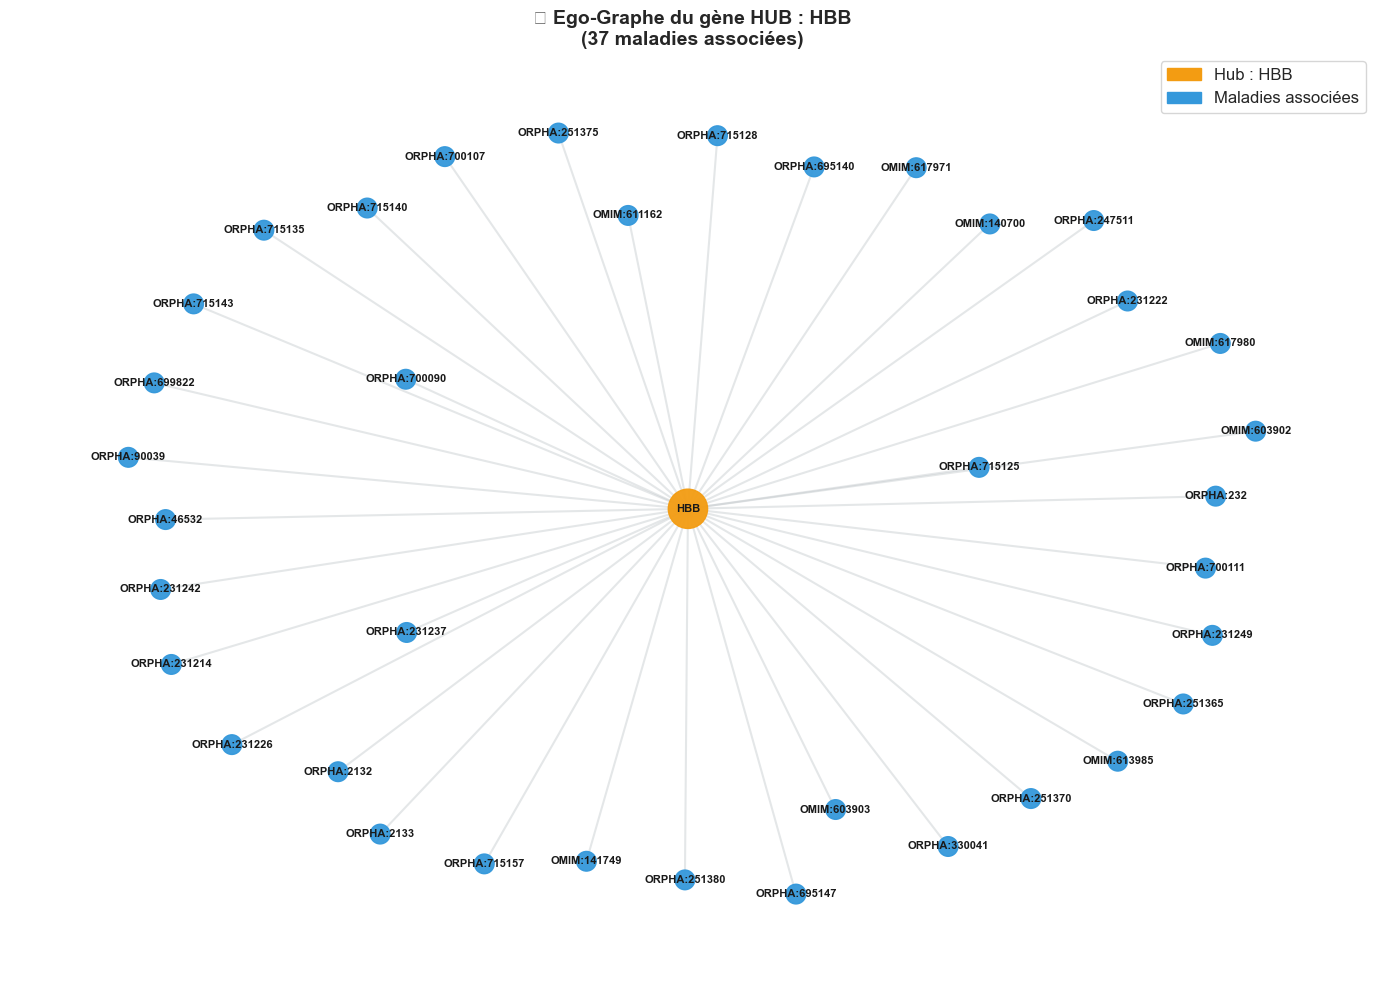

In [20]:
# ── Prendre le gène hub le plus connecté
top_gene_node = df_gene_deg.iloc[0]['gene_id']
top_gene_name = df_gene_deg.iloc[0]['gene_symbol']
top_gene_node_key = f'G_{top_gene_node}'

# ── Son ego-graphe (lui + tous ses voisins)
ego = nx.ego_graph(G, top_gene_node_key, radius=1)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(ego, seed=42, k=1.2)

node_colors_ego = []
node_sizes_ego  = []
for node in ego.nodes():
    if node == top_gene_node_key:
        node_colors_ego.append('#F39C12')   # doré = hub central
        node_sizes_ego.append(800)
    elif ego.nodes[node].get('node_type') == 'gene':
        node_colors_ego.append('#E74C3C')
        node_sizes_ego.append(300)
    else:
        node_colors_ego.append('#3498DB')
        node_sizes_ego.append(200)

nx.draw_networkx_edges(ego, pos, alpha=0.4, edge_color='#BDC3C7', width=1.5, ax=ax)
nx.draw_networkx_nodes(ego, pos, node_color=node_colors_ego,
                       node_size=node_sizes_ego, alpha=0.95, ax=ax)

labels_ego = {}
for node in ego.nodes():
    if node == top_gene_node_key:
        labels_ego[node] = top_gene_name
    elif ego.nodes[node].get('node_type') == 'disease':
        labels_ego[node] = node.replace('D_','')[:14]

nx.draw_networkx_labels(ego, pos, labels=labels_ego, font_size=8,
                        font_weight='bold', ax=ax)

patch_hub     = mpatches.Patch(color='#F39C12', label=f'Hub : {top_gene_name}')
patch_disease = mpatches.Patch(color='#3498DB', label='Maladies associées')
ax.legend(handles=[patch_hub, patch_disease], fontsize=12)
ax.set_title(f'⭐ Ego-Graphe du gène HUB : {top_gene_name}\n'
             f'({G.degree(top_gene_node_key)} maladies associées)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'ego_graph_{top_gene_name}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 📐 Cellule 10 — Métriques avancées du graphe

In [21]:
# Travail sur la plus grande composante uniquement
G_lcc = G.subgraph(largest_comp).copy()

print('⏳ Calcul des métriques avancées (quelques secondes)...')

# ── Coefficient de clustering moyen (projection gènes)
gene_nodes_lcc = [n for n in G_lcc.nodes() if G_lcc.nodes[n].get('node_type')=='gene']
gene_proj      = bipartite.projected_graph(G_lcc, gene_nodes_lcc)
avg_clustering = nx.average_clustering(gene_proj)

# ── Degré max
max_deg_gene    = max(gene_deg.values())
max_deg_disease = max(disease_deg.values())

# ── Nombre de nœuds avec degré = 1 (feuilles)
leaves_gene    = sum(1 for v in gene_deg.values() if v == 1)
leaves_disease = sum(1 for v in disease_deg.values() if v == 1)

print()
print('═' * 55)
print('   📐 MÉTRIQUES AVANCÉES')
print('═' * 55)
print(f'  Degré max gènes                 : {max_deg_gene}')
print(f'  Degré max maladies              : {max_deg_disease}')
print(f'  Gènes associés à 1 seule maladie: {leaves_gene} ({leaves_gene/n_genes*100:.1f}%)')
print(f'  Maladies liées à 1 seul gène    : {leaves_disease} ({leaves_disease/n_diseases*100:.1f}%)')
print(f'  Clustering moyen (proj. gènes)  : {avg_clustering:.4f}')
print(f'  Taille composante principale    : {len(G_lcc.nodes()):,} nœuds')
print('═' * 55)
print()
print('💡 Interprétation :')
print(f'   → {leaves_gene/n_genes*100:.0f}% des gènes sont associés à 1 seule maladie')
print(f'     → intéressant pour la prédiction (liens à découvrir !)')
print(f'   → Clustering = {avg_clustering:.4f} : les gènes causant les mêmes maladies')
print(f'     → ont tendance à se regrouper en modules fonctionnels')

⏳ Calcul des métriques avancées (quelques secondes)...

═══════════════════════════════════════════════════════
   📐 MÉTRIQUES AVANCÉES
═══════════════════════════════════════════════════════
  Degré max gènes                 : 37
  Degré max maladies              : 114
  Gènes associés à 1 seule maladie: 1265 (22.9%)
  Maladies liées à 1 seul gène    : 9702 (88.0%)
  Clustering moyen (proj. gènes)  : 0.8172
  Taille composante principale    : 8,396 nœuds
═══════════════════════════════════════════════════════

💡 Interprétation :
   → 23% des gènes sont associés à 1 seule maladie
     → intéressant pour la prédiction (liens à découvrir !)
   → Clustering = 0.8172 : les gènes causant les mêmes maladies
     → ont tendance à se regrouper en modules fonctionnels


## 💾 Cellule 11 — Sauvegarde du graphe

In [22]:
# ── Format GraphML (lisible par Gephi, Cytoscape, etc.)
graphml_path = os.path.join(GRAPH_DIR, 'gene_disease_graph.graphml')
nx.write_graphml(G, graphml_path)
print(f'✅ GraphML sauvegardé → {graphml_path}')

# ── Format pickle Python (chargement rapide pour les phases suivantes)
pickle_path = os.path.join(GRAPH_DIR, 'gene_disease_graph.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(G, f)
print(f'✅ Pickle sauvegardé  → {pickle_path}')

# ── Sauvegarder les listes de nœuds
nodes_path = os.path.join(GRAPH_DIR, 'node_types.csv')
rows = []
for n in G.nodes():
    rows.append({'node': n, 'type': G.nodes[n].get('node_type','?')})
pd.DataFrame(rows).to_csv(nodes_path, index=False)
print(f'✅ Types de nœuds     → {nodes_path}')

print()
print('📦 Fichiers produits dans data/graph/ :')
for f in os.listdir(GRAPH_DIR):
    fpath = os.path.join(GRAPH_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f'   {f:<35} ({size:.1f} KB)')

✅ GraphML sauvegardé → c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\graph\gene_disease_graph.graphml
✅ Pickle sauvegardé  → c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\graph\gene_disease_graph.pkl
✅ Types de nœuds     → c:\Users\EL MAHDI MAJDI\Desktop\recommandation-genes-maladies\data\graph\node_types.csv

📦 Fichiers produits dans data/graph/ :
   gene_disease_graph.graphml          (2510.4 KB)
   gene_disease_graph.pkl              (1088.9 KB)
   node_types.csv                      (321.3 KB)


## ✅ Cellule 12 — Résumé final de la Phase 3

In [35]:
print('╔═════════════════════════════════════════════════════╗')
print('║       ✅ PHASE 3 TERMINÉE AVEC SUCCÈS !             ║')
print('╠═════════════════════════════════════════════════════╣')
print(f'║  🕸️  Graphe biparti construit                       ║')
print(f'║  🧬  {n_genes:>5,} nœuds gènes                              ║')
print(f'║  🦠  {n_diseases:>5,} nœuds maladies                          ║')
print(f'║  🔗  {n_edges:>5,} arêtes (associations validées)          ║')
print(f'║  📉  Densité : {density:.6f} (graphe creux)              ║')
print(f'║  🔌  {n_components} composantes connexes                      ║')
print('╠═════════════════════════════════════════════════════╣')
print('║  📦 Fichiers produits :                            ║')
print('║     data/graph/gene_disease_graph.graphml           ║')
print('║     data/graph/gene_disease_graph.pkl               ║')
print('║     data/graph/node_types.csv                       ║')
print('║     results/figures/degree_distributions.png        ║')
print('║     results/figures/graphe_biparti_viz.png          ║')
print('╠═════════════════════════════════════════════════════╣')
print('║  ➡️  Prochaine étape : Phase 4                     ║')
print('║     Préparation Train/Test + exemples négatifs      ║')
print('╚═════════════════════════════════════════════════════╝')

╔═════════════════════════════════════════════════════╗
║       ✅ PHASE 3 TERMINÉE AVEC SUCCÈS !             ║
╠═════════════════════════════════════════════════════╣
║  🕸️  Graphe biparti construit                       ║
║  🧬  5,529 nœuds gènes                              ║
║  🦠  11,026 nœuds maladies                          ║
║  🔗  15,940 arêtes (associations validées)          ║
║  📉  Densité : 0.000261 (graphe creux)              ║
║  🔌  2381 composantes connexes                      ║
╠═════════════════════════════════════════════════════╣
║  📦 Fichiers produits :                            ║
║     data/graph/gene_disease_graph.graphml           ║
║     data/graph/gene_disease_graph.pkl               ║
║     data/graph/node_types.csv                       ║
║     results/figures/degree_distributions.png        ║
║     results/figures/graphe_biparti_viz.png          ║
╠═════════════════════════════════════════════════════╣
║  ➡️  Prochaine étape : Phase 4                     ║
║